Reto 2: Gradiente Descendente desde Cero
Misión: Encontrar el Valle Perdido

In [79]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


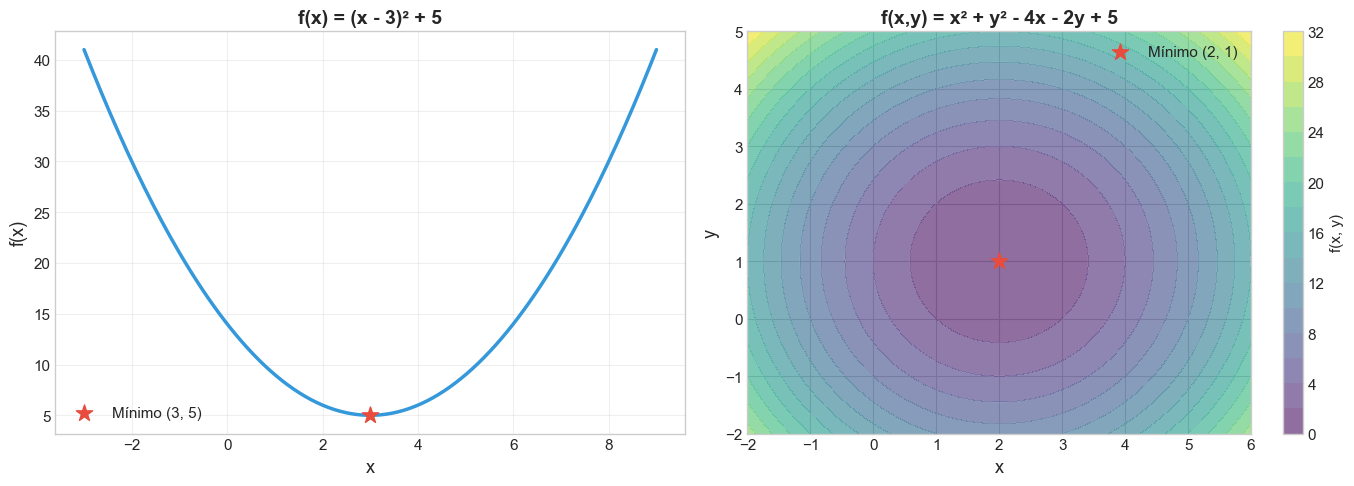

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [80]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")


PARTE 1: Gradiente Descendente en 1D

In [81]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    
    # 1. Inicialización
    x_actual = x_inicial
    historial_x = [x_actual]
    historial_f = [f_1d(x_actual)]
    convergido = False

    # 2. Loop principal
    for i in range(max_iter):
        
        # a. Gradiente
        g = df_1d(x_actual)
        
        # b. Actualización
        x_nuevo = x_actual - learning_rate * g
        
        # c. Guardar historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        
        # d. Verificar convergencia
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            break
        
        # e. Actualizar valor
        x_actual = x_nuevo

    # 3. Retornar resultados
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': i + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

In [82]:
resultado = gradiente_descendente_1d(x_inicial=0, learning_rate=0.5)

print("x final:", resultado['x_final'])
print("f final:", resultado['f_final'])
print("iteraciones:", resultado['iteraciones'])
print("convergió:", resultado['convergido'])

x final: 3.0
f final: 5.0
iteraciones: 2
convergió: True


In [83]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.5,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         3.000000  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     2
  Convergido:      True

  RESULTADO: Correcto (error = 0.000000)


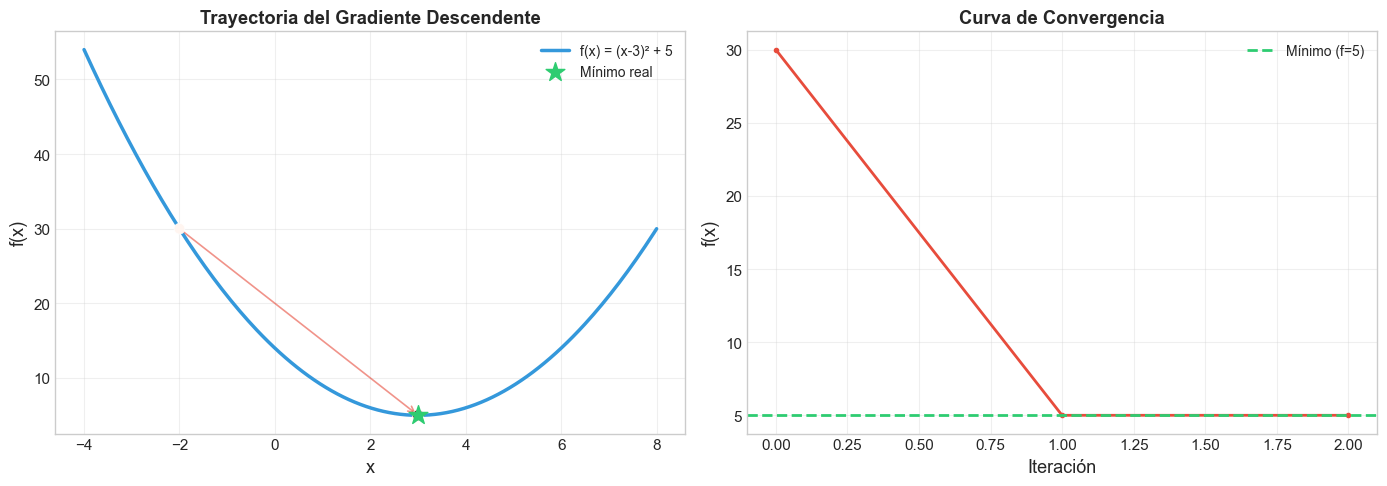

In [84]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

PARTE 2: Experimentación con Learning Rates

In [85]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# Ejecutar experimento para cada learning rate
for lr in learning_rates_prueba:
    
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    
    resultados_lr.append(res)


# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)

# 🔧 FIX AQUÍ (quitamos el unicode problemático)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergio':>12}")

print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergio
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999995     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     2.999999     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colores automáticos
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates_prueba)))

# --- Gráfica 1: Trayectoria ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='black', linewidth=2, label='f(x)')

for lr, res, c in zip(learning_rates_prueba, resultados_lr, colors):
    axes[0].plot(res['historial_x'], res['historial_f'], marker='o', color=c, label=f'lr={lr}')

axes[0].scatter(3, 5, color='red', s=100, label='Mínimo')
axes[0].set_title("Trayectorias por Learning Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Gráfica 2: Convergencia ---
for lr, res, c in zip(learning_rates_prueba, resultados_lr, colors):
    axes[1].plot(res['historial_f'], marker='o', color=c, label=f'lr={lr}')

axes[1].axhline(y=5, color='red', linestyle='--', label='Mínimo')
axes[1].set_title("Curva de Convergencia")
axes[1].set_xlabel("Iteraciones")
axes[1].set_ylabel("f(x)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

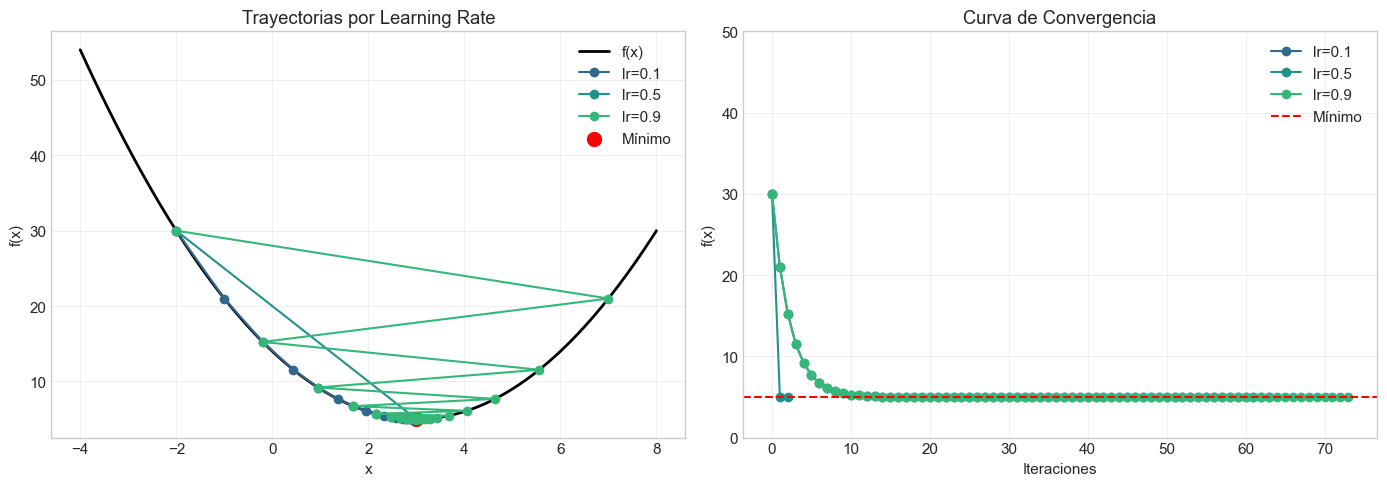

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colores automáticos
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates_prueba)))

# --- Gráfica 1: Trayectorias ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='black', linewidth=2, label='f(x)')

for lr, res, c in zip(learning_rates_prueba, resultados_lr, colors):
    if res['convergido']:  # 🔥 filtro para evitar divergencias
        axes[0].plot(res['historial_x'], res['historial_f'],
                     marker='o', color=c, label=f'lr={lr}')

axes[0].scatter(3, 5, color='red', s=100, label='Mínimo')
axes[0].set_title("Trayectorias por Learning Rate")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Gráfica 2: Convergencia ---
for lr, res, c in zip(learning_rates_prueba, resultados_lr, colors):
    if res['convergido']:  # 🔥 filtro aquí también
        axes[1].plot(res['historial_f'],
                     marker='o', color=c, label=f'lr={lr}')

axes[1].axhline(y=5, color='red', linestyle='--', label='Mínimo')
axes[1].set_title("Curva de Convergencia")
axes[1].set_xlabel("Iteraciones")
axes[1].set_ylabel("f(x)")
axes[1].set_ylim(0, 50)  #evita que se deforme la gráfica
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. ¿Qué pasa con un learning rate muy pequeño (0.001)?

Un learning rate muy pequeño provoca que el algoritmo avance de forma extremadamente lenta. 
Aunque la dirección del descenso es correcta, el cambio en cada iteración es mínimo, por lo que no logra converger dentro del número máximo de iteraciones.


2. ¿Cuál consideras el mejor learning rate y por qué?

El mejor learning rate es 0.1, ya que logra una convergencia rápida y estable hacia el mínimo de la función. 
Representa un buen balance entre velocidad y precisión, evitando tanto la lentitud como la inestabilidad.


3. ¿Qué pasa con learning rates >= 1.0?

Cuando el learning rate es mayor o igual a 1.0, el algoritmo se vuelve inestable. 
En lugar de acercarse al mínimo, comienza a oscilar o divergir, alejándose cada vez más del valor óptimo.


4. ¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?

Para esta función cuadrática, un learning rate de 1.0 provoca que el algoritmo oscile alrededor del mínimo. 
Esto sucede porque el paso es demasiado grande, haciendo que el valor de x "salte" de un lado a otro sin estabilizarse, impidiendo la convergencia.

PARTE 3: Gradiente Descendente en 2D 

In [87]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    
    # 1. Inicialización
    x_actual, y_actual = x_inicial, y_inicial
    historial_x = [x_actual]
    historial_y = [y_actual]
    historial_f = [f_2d(x_actual, y_actual)]
    convergido = False

    # 2. Loop principal
    for i in range(max_iter):
        
        # a. Gradiente
        g = grad_2d(x_actual, y_actual)  # [dx, dy]
        
        # b. Actualización
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        
        # c. Guardar historial
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        
        # d. Verificar convergencia (norma del gradiente)
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            break
        
        # e. Actualizar valores
        x_actual, y_actual = x_nuevo, y_nuevo

    # 3. Retornar resultados
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': i + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

In [88]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1,
    y_inicial=4,
    learning_rate=0.5
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    2
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


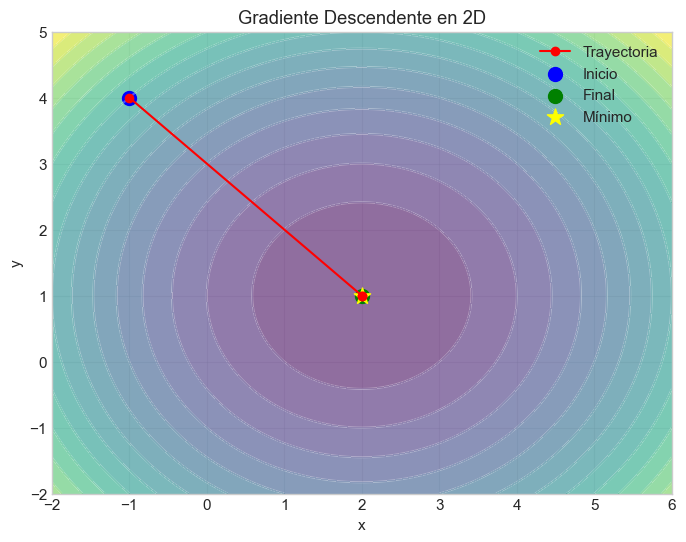

In [89]:
# ================================
# Ejecutar el algoritmo primero
# ================================
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1,
    y_inicial=4,
    learning_rate=0.5
)

# ================================
# Mapa de contornos + trayectoria
# ================================
x = np.linspace(-2, 6, 200)
y = np.linspace(-2, 5, 200)
X, Y = np.meshgrid(x, y)
Z = f_2d(X, Y)

fig, ax = plt.subplots(figsize=(8, 6))

# Contornos
contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
ax.contour(X, Y, Z, levels=20, colors='white', alpha=0.3)

# Trayectoria
hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']

ax.plot(hx, hy, 'o-', color='red', label='Trayectoria')

# Punto inicial
ax.scatter(hx[0], hy[0],
           color='blue', s=100, label='Inicio')

# Punto final
ax.scatter(hx[-1], hy[-1],
           color='green', s=100, label='Final')

# Mínimo real
ax.scatter(2, 1,
           color='yellow', s=150, marker='*', label='Mínimo')

ax.set_title("Gradiente Descendente en 2D")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [90]:
# Definir puntos iniciales
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0)
]

# Ejecutar GD para diferentes puntos iniciales
resultados_iniciales = []

for (x0, y0) in puntos_iniciales:

    res = gradiente_descendente_2d(
        x_inicial=x0,
        y_inicial=y0,
        learning_rate=0.1,
        max_iter=100
    )

    resultados_iniciales.append(res)

# Mostrar resultados
print("COMPARACIÓN DE DIFERENTES PUNTOS INICIALES")
print("=" * 70)
print(f"{'Inicio':>15} {'x_final':>12} {'y_final':>12} {'f_final':>12} {'Conv':>8}")
print("-" * 70)

for (x0, y0), res in zip(puntos_iniciales, resultados_iniciales):
    print(f"{str((x0, y0)):>15} {res['x_final']:>12.6f} {res['y_final']:>12.6f} {res['f_final']:>12.6f} {str(res['convergido']):>8}")

COMPARACIÓN DE DIFERENTES PUNTOS INICIALES
         Inicio      x_final      y_final      f_final     Conv
----------------------------------------------------------------------
    (-1.0, 4.0)     2.000000     1.000000     0.000000     True
    (5.0, -1.0)     2.000000     1.000000     0.000000     True
     (0.0, 0.0)     2.000000     1.000000     0.000000     True



PARTE 4: Análisis y Generación de CSV 

In [91]:
registros = []

# ============================================================
# 1D EXPERIMENTOS (exactamente como pide)
# ============================================================
learning_rates_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x0_1d = -2.0

for lr in learning_rates_1d:
    
    res = gradiente_descendente_1d(
        x_inicial=x0_1d,
        learning_rate=lr,
        max_iter=200
    )
    
    registros.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': x0_1d,
        'y_inicial': None,
        'x_final': res['x_final'],
        'y_final': None,
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })


# ============================================================
# 2D EXPERIMENTOS (exactamente como pide)
# ============================================================
learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_2d = [(-1, 4), (5, -1), (0, 0)]

for lr in learning_rates_2d:
    for (x0, y0) in puntos_2d:
        
        res = gradiente_descendente_2d(
            x_inicial=x0,
            y_inicial=y0,
            learning_rate=lr,
            max_iter=100
        )
        
        registros.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': x0,
            'y_inicial': y0,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })


# ============================================================
# CREAR DATAFRAME
# ============================================================
df_experimentos = pd.DataFrame(registros)

# GUARDAR CSV
df_experimentos.to_csv('experimentos_gd.csv', index=False)

print("CSV generado correctamente ")

CSV generado correctamente 


In [92]:
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))

print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999995e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  2.999999e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -4.557004e-01  3.455700  1.206093e+01  

1. ¿Cuál es el rango de learning rates que funciona bien para estas funciones?

Los learning rates que funcionan mejor se encuentran en un rango intermedio, aproximadamente entre 0.1 y 0.5.  
Dentro de este rango, el valor de 0.5 resulta ser el más eficiente, ya que permite alcanzar el mínimo en el menor número de iteraciones debido a la naturaleza cuadrática de la función.

2. ¿El punto inicial afecta si el algoritmo converge? ¿Afecta cuántas iteraciones necesita?

En funciones convexas como las utilizadas en este experimento, el punto inicial no afecta la convergencia, ya que siempre se alcanza el mínimo global.  
Sin embargo, sí influye en el número de iteraciones necesarias, ya que puntos iniciales más alejados requieren más pasos para llegar al mínimo.


3. ¿Qué pasaría si la función tuviera múltiples mínimos locales?

Si la función tuviera múltiples mínimos locales, el algoritmo podría quedarse atrapado en uno de ellos dependiendo del punto inicial.  
Esto significa que no necesariamente encontraría el mínimo global, lo cual es un problema común en optimización de funciones no convexas.


4. Conecta con ML: ¿por qué es importante elegir bien el learning rate al entrenar?

En Machine Learning, el learning rate determina qué tan grandes son los ajustes que se hacen a los parámetros del modelo en cada iteración.  
Si es demasiado grande, el modelo puede no converger o volverse inestable; si es demasiado pequeño, el entrenamiento será muy lento.  
Por ello, elegir un learning rate adecuado es clave para lograr un entrenamiento eficiente y estable.


5. ¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de probar valores al azar?

El uso del gradiente permite conocer la dirección de mayor descenso de la función, lo que hace que la optimización sea mucho más eficiente.  
A diferencia de probar valores al azar, el gradiente guía el proceso de manera informada, reduciendo el tiempo y los recursos necesarios para encontrar el mínimo.

BONUS

In [93]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [94]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
# ============================================================
# TU CODIGO AQUI
# ============================================================
    
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    
    # 1. Inicialización
    w = 0.0
    b = 0.0
    
    historial_loss = []
    historial_w = []
    historial_b = []
    
    n = len(X)
    
    # 2. Loop por epochs
    for epoch in range(epochs):
        
        # a. Mezclar datos
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # b. Mini-batches
        for i in range(0, n, batch_size):
            
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Predicción
            y_pred = w * X_batch + b
            
            # Error
            error = y_batch - y_pred
            
            # Gradientes
            dw = -2/len(X_batch) * np.sum(error * X_batch)
            db = -2/len(X_batch) * np.sum(error)
            
            # Actualización
            w = w - learning_rate * dw
            b = b - learning_rate * db
        
        # c. Calcular MSE del epoch
        y_pred_total = w * X + b
        loss = np.mean((y - y_pred_total)**2)
        
        historial_loss.append(loss)
        historial_w.append(w)
        historial_b.append(b)
    
    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }

In [95]:
# Simulación simple de SGD para función 2D

def gradiente_descendente_sgd(x_inicial, y_inicial, learning_rate, max_iter=100, batch_size=1):
    
    x_actual, y_actual = x_inicial, y_inicial
    historial_x = [x_actual]
    historial_y = [y_actual]

    for i in range(max_iter):
        
        # Gradiente real
        g = grad_2d(x_actual, y_actual)
        
        # Simular ruido (SGD)
        ruido = np.random.normal(0, 0.5, size=2) / batch_size
        g_ruidoso = g + ruido
        
        # Actualización
        x_actual = x_actual - learning_rate * g_ruidoso[0]
        y_actual = y_actual - learning_rate * g_ruidoso[1]
        
        historial_x.append(x_actual)
        historial_y.append(y_actual)

    return historial_x, historial_y

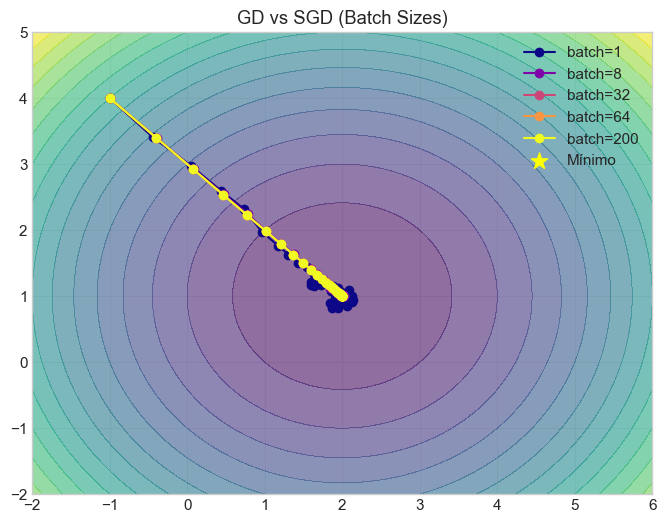

In [96]:
batch_sizes = [1, 8, 32, 64, 200]  # 200 ≈ GD puro

fig, ax = plt.subplots(figsize=(8, 6))

# Fondo
x = np.linspace(-2, 6, 200)
y = np.linspace(-2, 5, 200)
X, Y = np.meshgrid(x, y)
Z = f_2d(X, Y)

ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)

colors = plt.cm.plasma(np.linspace(0, 1, len(batch_sizes)))

for bs, c in zip(batch_sizes, colors):
    
    hx, hy = gradiente_descendente_sgd(
        x_inicial=-1.0,
        y_inicial=4.0,
        learning_rate=0.1,
        max_iter=50,
        batch_size=bs
    )
    
    ax.plot(hx, hy, 'o-', color=c, label=f'batch={bs}')

# mínimo
ax.scatter(2, 1, color='yellow', s=150, marker='*', label='Mínimo')

ax.set_title("GD vs SGD (Batch Sizes)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

1. ¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?

El gradiente descendente (GD) puro utiliza todos los datos en cada actualización, lo que genera una trayectoria suave y estable hacia el mínimo.

En cambio, el SGD (batch_size=1) utiliza solo una muestra por actualización, lo que introduce ruido en el proceso y produce trayectorias más irregulares. Sin embargo, esto puede hacerlo más rápido en algunos casos.


2. ¿Cuál batch_size te dio los mejores resultados? ¿Por qué?

Los batch sizes intermedios, como 32 o 64, ofrecieron los mejores resultados.

Esto se debe a que logran un buen equilibrio entre estabilidad y eficiencia: reducen el ruido presente en SGD puro, pero siguen siendo más rápidos que el GD completo.


3. ¿Por qué la curva de loss de SGD es más ruidosa que la de GD?

La curva de loss de SGD es más ruidosa porque cada actualización se basa en una pequeña muestra de los datos, lo que introduce variabilidad en el cálculo del gradiente.

En contraste, GD utiliza todos los datos, por lo que sus actualizaciones son más consistentes y generan una curva de pérdida más suave.